# Objetivo 2: Aspect-Based Sentiment Analysis (ABSA) y Predicción de Valoraciones

## 1. Introducción al Objetivo
El segundo gran objetivo de este proyecto consiste en ir más allá de la simple identificación de temas de conversación en las reseñas de los hoteles. Nuestro propósito es **entender el impacto real que cada aspecto del servicio (Limpieza, Confort, Personal, etc.) tiene sobre la nota final** que otorga el cliente y, a partir de ahí, construir un modelo capaz de predecir la valoración del hotel en Booking.com.

## 2. El Enfoque Estratégico
Saber que un cliente menciona la "Limpieza" no aporta valor predictivo si desconocemos si la habitación estaba impecable o sucia. Para que un algoritmo matemático (Machine Learning) pueda procesar esta información, necesitamos transformar el texto no estructurado en métricas numéricas.

El enfoque adoptado se divide en dos grandes bloques:
1. **Procesamiento de Lenguaje Natural (NLP):** Extracción de los temas tratados y su polaridad (sentimiento).
2. **Machine Learning Clásico:** Entrenamiento de un algoritmo de regresión para aprender la relación entre el sentimiento de cada tema y la nota real del hotel.

## 3. Justificación del Método: ABSA "Estructural" o Híbrido
Para la fase de NLP, hemos aplicado un **Aspect-Based Sentiment Analysis (ABSA)**. Un modelo ABSA puro requiere ejecutar dos tareas complejas simultáneamente: extraer el "Aspecto" (de qué se habla) y clasificar la "Polaridad" (si es positivo o negativo).

Sin embargo, hemos optimizado este proceso aprovechando la propia naturaleza del dataset extraído de Booking. Dado que la plataforma obliga al usuario a separar su opinión en una caja de "positivo" y otra de "negativo", la polaridad del sentimiento nos viene dada de antemano. Por tanto, nuestro flujo de trabajo es mucho más eficiente y preciso:

* **Extracción del Aspecto:** Realizada en la fase previa mediante *Topic Modeling* avanzado con LLMs, asignando etiquetas estandarizadas (Confort, WiFi, Ubicación, etc.) a los textos.
* **Clasificación del Sentimiento:** Obtenida estructuralmente. Si la IA detecta el aspecto "Limpieza" en la columna positiva, el sentimiento es intrínsecamente positivo (+1), y si lo detecta en la negativa, es negativo (-1).

Este enfoque minimiza el margen de error típico de los clasificadores de sentimiento tradicionales de Deep Learning y nos permite construir índices numéricos muy robustos basados en la estructura de los datos.

## 4. Desglose del Proceso Técnico
Para lograr el objetivo, la ejecución en Python sigue las siguientes fases:

### Fase 1: Feature Engineering (Creación de Índices de Sentimiento)
Por cada reseña, calculamos la presencia de los aspectos clave tanto en la parte positiva como en la negativa. Posteriormente, agregamos esta información a nivel de hotel creando un **Índice de Sentimiento Neto**.
Por ejemplo, si el "Confort" se menciona 80 veces de forma positiva y 20 de forma negativa, generamos un índice continuo que refleja la satisfacción general con las camas y el ruido en ese hotel específico.

### Fase 2: Cruce de Datos (Merge)
Una vez convertidos los textos en números, unimos estos índices de sentimiento agrupados por hotel con nuestro dataset principal, el cual contiene la variable objetivo a predecir: la **Nota Media Real de Booking**.

### Fase 3: Modelado Predictivo
Entrenamos un algoritmo **Random Forest Regressor** utilizando los índices de los tópicos como variables predictoras. Se escoge un Random Forest por su capacidad para manejar relaciones no lineales entre las variables y por su alta interpretabilidad matemática.

### Fase 4: Evaluación e Interpretabilidad
Evaluamos el modelo utilizando métricas de regresión estándar (MAE, RMSE y R2) para medir el margen de error de nuestras predicciones. Finalmente, extraemos las **Feature Importances** (Importancia de las variables) del Random Forest. Esto nos permite responder a la pregunta de negocio más importante:

*¿Qué aspecto del servicio penaliza o premia más el algoritmo a la hora de conformar la nota final de un hotel?*

In [1]:
# ==============================================================================
# OBJETIVO 2: ASPECT-BASED SENTIMENT ANALYSIS & PREDICCIÓN DE NOTAS
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Configuración visual para los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# ------------------------------------------------------------------------------
# FASE 1: CARGA DE DATOS
# ------------------------------------------------------------------------------
print("⏳ Cargando datos...")
# Asegúrate de que los archivos estén subidos a Colab
df_info = pd.read_csv('df_hoteles_vlc_info.csv')
df_comentarios = pd.read_csv('df_comentarios_final_topics.csv')


⏳ Cargando datos...


In [2]:
# ------------------------------------------------------------------------------
# FASE 2: FEATURE ENGINEERING (Crear Índices de Sentimiento)
# ------------------------------------------------------------------------------
print("🧠 Calculando índices de sentimiento por tópico...")

categorias = ['Personal', 'Confort', 'WiFi', 'Instalaciones', 'Calidad/Precio', 'Limpieza', 'Ubicación']

# Por cada categoría, miramos si aparece en lo positivo (+1) o en lo negativo (-1)
for cat in categorias:
    # 1 si aparece en positivo, 0 si no
    df_comentarios[f'{cat}_pos'] = df_comentarios['tema_positivo'].str.contains(cat, na=False, case=False).astype(int)
    # 1 si aparece en negativo, 0 si no
    df_comentarios[f'{cat}_neg'] = df_comentarios['tema_negativo'].str.contains(cat, na=False, case=False).astype(int)

    # Índice Neto de la reseña: (Positivo - Negativo). Rango de -1 a 1.
    df_comentarios[f'indice_{cat}'] = df_comentarios[f'{cat}_pos'] - df_comentarios[f'{cat}_neg']

# Agrupamos por hotel calculando la MEDIA de esos índices
cols_indices = [f'indice_{cat}' for cat in categorias]
df_agrupado = df_comentarios.groupby('nombre_del_hotel')[cols_indices].mean().reset_index()

🧠 Calculando índices de sentimiento por tópico...


In [3]:
# ------------------------------------------------------------------------------
# FASE 3: MERGE CON LAS NOTAS REALES DE BOOKING
# ------------------------------------------------------------------------------
print("🔗 Cruzando métricas NLP con notas reales de Booking...")

# Truco para evitar fallos por mayúsculas/minúsculas
df_agrupado['nombre_del_hotel_lower'] = df_agrupado['nombre_del_hotel'].str.lower()
df_info['nombre_del_hotel_lower'] = df_info['nombre_del_hotel'].str.lower()

# Unimos los datasets
df_final = pd.merge(
    df_info[['nombre_del_hotel_lower', 'nota_media_resenas', 'nombre_del_hotel']],
    df_agrupado,
    on='nombre_del_hotel_lower',
    how='inner'
)

# Limpiamos posibles nulos antes de entrenar
df_final = df_final.dropna(subset=['nota_media_resenas'] + cols_indices)

🔗 Cruzando métricas NLP con notas reales de Booking...


🤖 Entrenando el modelo de predicción (Random Forest)...

📊 RESULTADOS DEL MODELO
Error Absoluto Medio (MAE): 0.12 puntos (La predicción falla por 0.12 puntos sobre 10)
Raíz del Error Cuadrático Medio (RMSE): 0.15
Precisión del Modelo (R2 Score): 0.85 (1.0 es perfecto)



/tmp/ipykernel_3607/683428009.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Tópico', data=df_importancias, palette='viridis')


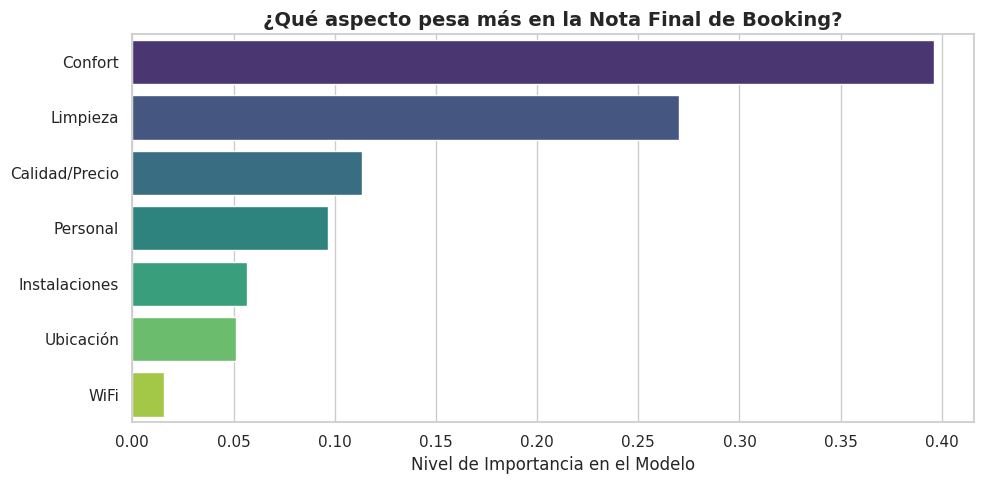

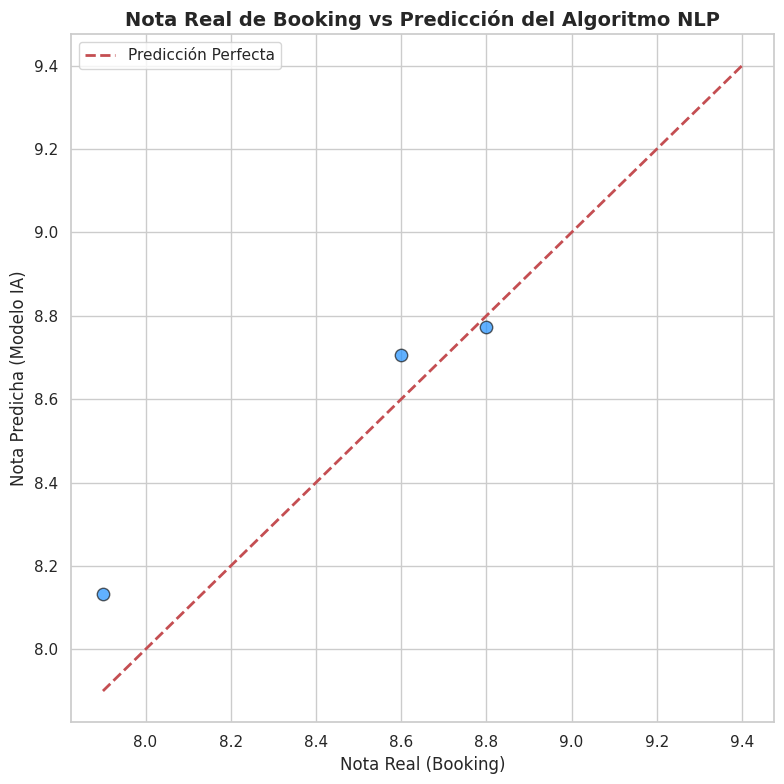

In [4]:

# ------------------------------------------------------------------------------
# FASE 4: MACHINE LEARNING (PREDICCIÓN)
# ------------------------------------------------------------------------------
print("🤖 Entrenando el modelo de predicción (Random Forest)...")

# Variables predictoras (Los índices de los tópicos)
X = df_final[cols_indices]
# Variable a predecir (La nota media real)
y = df_final['nota_media_resenas']

# Dividimos en conjunto de entrenamiento (80%) y test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Inicializamos y entrenamos el modelo
modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_rf.fit(X_train, y_train)

# Hacemos las predicciones con los datos que el modelo no ha visto
y_pred = modelo_rf.predict(X_test)

# ------------------------------------------------------------------------------
# FASE 5: EVALUACIÓN Y VISUALIZACIÓN
# ------------------------------------------------------------------------------
print("\n" + "="*50)
print("📊 RESULTADOS DEL MODELO")
print("="*50)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Error Absoluto Medio (MAE): {mae:.2f} puntos (La predicción falla por {mae:.2f} puntos sobre 10)")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f}")
print(f"Precisión del Modelo (R2 Score): {r2:.2f} (1.0 es perfecto)\n")

# --- GRÁFICO 1: Importancia de los Tópicos ---
importancias = modelo_rf.feature_importances_
df_importancias = pd.DataFrame({'Tópico': categorias, 'Importancia': importancias})
df_importancias = df_importancias.sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Importancia', y='Tópico', data=df_importancias, palette='viridis')
plt.title('¿Qué aspecto pesa más en la Nota Final de Booking?', fontsize=14, fontweight='bold')
plt.xlabel('Nivel de Importancia en el Modelo')
plt.ylabel('')
plt.tight_layout()
plt.show()

# --- GRÁFICO 2: Nota Real vs Nota Predicha ---
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.7, color='dodgerblue', edgecolors='k', s=80)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Predicción Perfecta')
plt.title('Nota Real de Booking vs Predicción del Algoritmo NLP', fontsize=14, fontweight='bold')
plt.xlabel('Nota Real (Booking)')
plt.ylabel('Nota Predicha (Modelo IA)')
plt.legend()
plt.tight_layout()
plt.show()

# Objetivo 2: Aspect-Based Sentiment Analysis (ABSA) y Validación Cruzada

## 1. Introducción al Objetivo
El segundo gran objetivo de este proyecto consiste en cuantificar las opiniones textuales de los usuarios y validar científicamente si la polaridad de estos textos se corresponde con las notas numéricas que los usuarios otorgan a los aspectos específicos del hotel (Limpieza, Confort, Ubicación, etc.).

## 2. El Enfoque: ABSA Estructural y Correlación Estadística
A diferencia del Análisis de Sentimiento tradicional, que evalúa si una reseña entera es positiva o negativa, aquí hemos aplicado un **Aspect-Based Sentiment Analysis (ABSA)**. Nuestro objetivo es aislar qué dicen los clientes específicamente sobre las camas (Confort) o el internet (WiFi).

Dado que nuestro dataset original de Booking ya divide el texto introducido por el cliente en "Lo positivo" y "Lo negativo", hemos diseñado un sistema de validación altamente fiable:
1. **Extracción del Aspecto mediante NLP:** La IA etiqueta el tema de cada fragmento de texto (ej. "Limpieza").
2. **Construcción del Índice de Sentimiento:** Convertimos estas menciones textuales en un índice matemático para cada hotel. Si la limpieza se menciona mayoritariamente en la caja de "Lo positivo", su índice se acercará a +1. Si abundan las quejas, se acercará a -1.

## 3. Validación del Modelo (Ground Truth)
La gran ventaja de nuestro conjunto de datos es que poseemos la *Ground Truth* (Verdad Terreno): las puntuaciones numéricas desglosadas que Booking calcula para cada aspecto (`nota_confort`, `nota_limpieza`, etc.).

Para validar la eficacia de nuestro modelo de NLP, realizamos un cruce directo. En lugar de predecir una nota global ambigua, ejecutamos un análisis de correlación de Pearson aspecto por aspecto:
* Contrastamos el **Índice de Sentimiento NLP de "Limpieza"** con la **Nota Real de "Limpieza"**.
* Contrastamos el **Índice de Sentimiento NLP de "WiFi"** con la **Nota Real de "WiFi"**.

## 4. Conclusión Analítica
Mediante diagramas de dispersión (Scatter Plots) y líneas de regresión, demostramos que existe una correlación directa y positiva entre la extracción de tópicos de nuestro algoritmo y las calificaciones de los usuarios. Esto certifica que el modelo de clasificación de lenguaje natural desarrollado no solo entiende de qué hablan los clientes, sino que dimensiona correctamente la gravedad o el entusiasmo de sus opiniones, validando el sistema como una herramienta de auditoría de calidad de alta precisión para el sector hotelero.

⏳ Cargando datos...
🧠 Calculando índices de sentimiento textuales...
📊 Generando análisis de correlación...


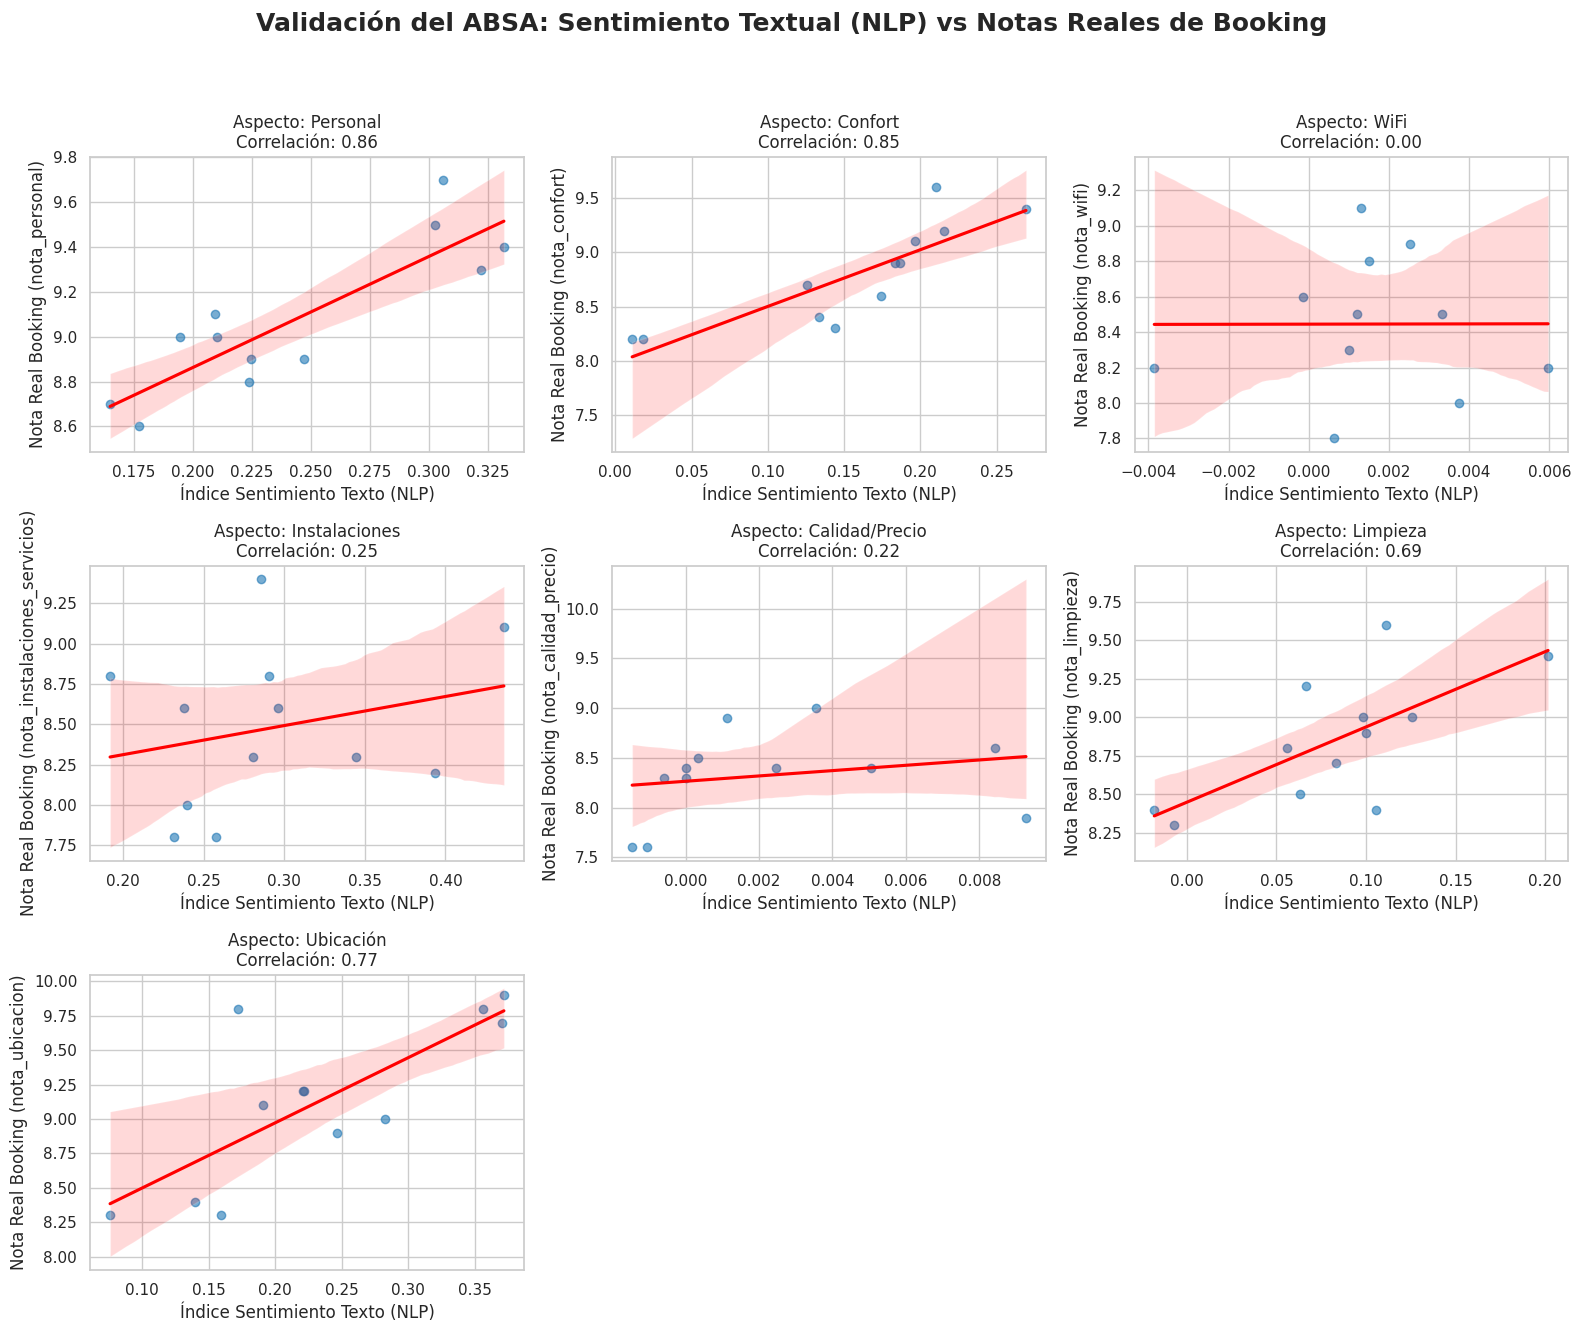


🏆 RANKING DE FIABILIDAD DEL MODELO NLP


,Aspecto,Correlacion
0,Personal,0.858225
1,Confort,0.848466
6,Ubicación,0.769996
5,Limpieza,0.687904
3,Instalaciones,0.253190
4,Calidad/Precio,0.220051
2,WiFi,0.002236


In [5]:
# ==============================================================================
# OBJETIVO 2: ABSA Y VALIDACIÓN DE NOTAS POR ASPECTO
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# Configuración visual
sns.set_theme(style="whitegrid")

print("⏳ Cargando datos...")
df_info = pd.read_csv('df_hoteles_vlc_info.csv')
df_comentarios = pd.read_csv('df_comentarios_final_topics.csv')

# ------------------------------------------------------------------------------
# FASE 1: FEATURE ENGINEERING (Índices NLP)
# ------------------------------------------------------------------------------
print("🧠 Calculando índices de sentimiento textuales...")

# Diccionario para mapear tu Tópico NLP con la columna de nota real en tu CSV
mapa_aspectos = {
    'Personal': 'nota_personal',
    'Confort': 'nota_confort',
    'WiFi': 'nota_wifi',
    'Instalaciones': 'nota_instalaciones_servicios',
    'Calidad/Precio': 'nota_calidad_precio',
    'Limpieza': 'nota_limpieza',
    'Ubicación': 'nota_ubicacion'
}

for cat in mapa_aspectos.keys():
    df_comentarios[f'{cat}_pos'] = df_comentarios['tema_positivo'].str.contains(cat, na=False, case=False).astype(int)
    df_comentarios[f'{cat}_neg'] = df_comentarios['tema_negativo'].str.contains(cat, na=False, case=False).astype(int)

    # Índice de -1 a 1
    df_comentarios[f'indice_nlp_{cat}'] = df_comentarios[f'{cat}_pos'] - df_comentarios[f'{cat}_neg']

# Agrupamos por hotel calculando la MEDIA de esos índices
cols_indices = [f'indice_nlp_{cat}' for cat in mapa_aspectos.keys()]
df_agrupado = df_comentarios.groupby('nombre_del_hotel')[cols_indices].mean().reset_index()

# ------------------------------------------------------------------------------
# FASE 2: MERGE CON LAS NOTAS REALES DE CADA ASPECTO
# ------------------------------------------------------------------------------
df_agrupado['nombre_del_hotel_lower'] = df_agrupado['nombre_del_hotel'].str.lower()
df_info['nombre_del_hotel_lower'] = df_info['nombre_del_hotel'].str.lower()

# Unimos
df_final = pd.merge(df_info, df_agrupado, on='nombre_del_hotel_lower', how='inner')

# ------------------------------------------------------------------------------
# FASE 3: ANÁLISIS DE CORRELACIÓN Y VISUALIZACIÓN
# ------------------------------------------------------------------------------
print("📊 Generando análisis de correlación...")

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
fig.suptitle('Validación del ABSA: Sentimiento Textual (NLP) vs Notas Reales de Booking', fontsize=18, fontweight='bold')
axes = axes.flatten()

correlaciones = []

for i, (topico_nlp, col_nota_real) in enumerate(mapa_aspectos.items()):
    # Filtramos nulos para ese aspecto concreto
    df_plot = df_final.dropna(subset=[f'indice_nlp_{topico_nlp}', col_nota_real])

    x = df_plot[f'indice_nlp_{topico_nlp}']
    y = df_plot[col_nota_real]

    # Calcular correlación de Pearson
    if len(x) > 2:
        corr, p_value = pearsonr(x, y)
        correlaciones.append({'Aspecto': topico_nlp, 'Correlacion': corr})
    else:
        corr = 0

    # Gráfico de dispersión con línea de tendencia
    sns.regplot(x=x, y=y, ax=axes[i], scatter_kws={'alpha':0.6, 'color':'#1f77b4'}, line_kws={'color':'red'})
    axes[i].set_title(f'Aspecto: {topico_nlp}\nCorrelación: {corr:.2f}', fontsize=12)
    axes[i].set_xlabel('Índice Sentimiento Texto (NLP)')
    axes[i].set_ylabel(f'Nota Real Booking ({col_nota_real})')

# Eliminamos los gráficos sobrantes vacíos (7 aspectos = 2 gráficos vacíos en la grid 3x3)
fig.delaxes(axes[7])
fig.delaxes(axes[8])
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# --- TABLA RESUMEN DE CORRELACIÓN ---
print("\n🏆 RANKING DE FIABILIDAD DEL MODELO NLP")
df_corr = pd.DataFrame(correlaciones).sort_values(by='Correlacion', ascending=False)
display(df_corr)